In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from statsbombpy import sb

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pass_heatmap import (
    load_matches,
    load_events,
    filter_passes,
    filter_player_passes,
    prepare_pass_coordinates,
    add_pass_features,
    calculate_pass_metrics,
    create_metrics_summary
)

In [5]:
# Final analysis parameters

COMPETITION_ID = 55
SEASON_ID = 282
MATCH_ID = 3943043

PLAYER_NAME = "Robin Aime Robert Le Normand"
DATA_SOURCE = "StatsBomb Open Data"
EVENT_TYPE = "Pass"
ANALYSIS_TYPE = "Pass density heatmap"

In [6]:
competitions = sb.competitions()

selected_competition = competitions[
    (competitions["competition_id"] == COMPETITION_ID)
    & (competitions["season_id"] == SEASON_ID)
].iloc[0]

COMPETITION_NAME = selected_competition["competition_name"]
SEASON_NAME = selected_competition["season_name"]
COUNTRY_NAME = selected_competition["country_name"]

COMPETITION_NAME, SEASON_NAME, COUNTRY_NAME

('UEFA Euro', '2024', 'Europe')

In [7]:
matches = sb.matches(
    competition_id=COMPETITION_ID,
    season_id=SEASON_ID
)

selected_match = matches[
    matches["match_id"] == MATCH_ID
].iloc[0]

MATCH_DATE = selected_match["match_date"]
HOME_TEAM = selected_match["home_team"]
AWAY_TEAM = selected_match["away_team"]
HOME_SCORE = selected_match["home_score"]
AWAY_SCORE = selected_match["away_score"]
COMPETITION_STAGE = selected_match["competition_stage"]

MATCH_LABEL = f"{HOME_TEAM} {HOME_SCORE} - {AWAY_SCORE} {AWAY_TEAM}"

MATCH_LABEL, MATCH_DATE, COMPETITION_STAGE

('Spain 2 - 1 England', '2024-07-14', 'Final')

In [8]:
events = sb.events(match_id=MATCH_ID)

events.shape

(3312, 92)

In [9]:
events["type"].value_counts().head(20)

type
Pass               917
Ball Receipt*      878
Carry              759
Pressure           327
Ball Recovery       71
Duel                70
Block               43
Clearance           43
Goal Keeper         30
Shot                25
Dribble             24
Dispossessed        23
Foul Committed      19
Foul Won            19
Miscontrol          12
Dribbled Past       10
Interception         7
Substitution         7
Injury Stoppage      6
Half Start           4
Name: count, dtype: int64

In [10]:
players = (
    events[["team", "player", "position"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["team", "player"])
)

players[
    players["player"].str.contains("Le Normand", case=False, na=False)
]

,team,player,position
9,Spain,Robin Aime Robert Le Normand,Right Center Back


In [11]:
passes = events[events["type"] == "Pass"].copy()

passes.shape

(917, 92)

In [12]:
passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "location",
        "pass_end_location",
        "pass_outcome",
        "pass_length",
        "pass_angle",
        "pass_height",
        "pass_recipient"
    ]
].head()

,team,player,position,minute,second,location,pass_end_location,pass_outcome,pass_length,pass_angle,pass_height,pass_recipient
6,England,Kobbie Mainoo,Right Defensive Midfield,0,0,"[60.0, 40.0]","[25.4, 38.8]",NaN,34.620804,-3.106924,Ground Pass,Jordan Pickford
7,England,Jordan Pickford,Goalkeeper,0,4,"[28.7, 31.6]","[120.0, 67.7]",Out,98.177900,0.376534,High Pass,Bukayo Saka
8,Spain,Unai Simón Mendibil,Goalkeeper,0,34,"[6.9, 39.6]","[9.1, 57.2]",NaN,17.736967,1.446441,Ground Pass,Robin Aime Robert Le Normand
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,"[8.9, 57.2]","[20.6, 75.8]",NaN,21.973848,1.009303,Ground Pass,Daniel Carvajal Ramos
10,Spain,Daniel Carvajal Ramos,Right Back,0,39,"[28.6, 76.4]","[50.2, 68.5]",NaN,22.999348,-0.350628,Ground Pass,Daniel Olmo Carvajal


In [13]:
player_passes = passes[
    passes["player"] == PLAYER_NAME
].copy()

player_passes.shape

(84, 92)

In [14]:
len(player_passes)

84

In [15]:
player_passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "location",
        "pass_end_location",
        "pass_outcome",
        "pass_length",
        "pass_height",
        "pass_recipient"
    ]
].head()

,team,player,position,minute,second,location,pass_end_location,pass_outcome,pass_length,pass_height,pass_recipient
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,"[8.9, 57.2]","[20.6, 75.8]",NaN,21.973848,Ground Pass,Daniel Carvajal Ramos
17,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,"[23.3, 60.1]","[27.4, 33.8]",NaN,26.617662,Ground Pass,Aymeric Laporte
19,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,"[42.9, 54.1]","[43.5, 25.2]",NaN,28.906227,Ground Pass,Aymeric Laporte
25,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,"[29.0, 67.8]","[34.9, 76.0]",NaN,10.101980,Ground Pass,Daniel Carvajal Ramos
30,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,"[29.2, 64.7]","[3.8, 45.5]",NaN,31.840225,Ground Pass,Unai Simón Mendibil


In [16]:
TEAM_NAME = player_passes["team"].mode()[0]
POSITION_NAME = player_passes["position"].mode()[0]

TEAM_NAME, POSITION_NAME

('Spain', 'Right Center Back')

In [17]:
def extract_coordinate(value, index):
    if isinstance(value, list) and len(value) > index:
        return value[index]
    return np.nan

In [18]:
player_passes["x"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["y"] = player_passes["location"].apply(
    lambda value: extract_coordinate(value, 1)
)

player_passes["end_x"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 0)
)

player_passes["end_y"] = player_passes["pass_end_location"].apply(
    lambda value: extract_coordinate(value, 1)
)

In [19]:
player_passes["is_completed"] = player_passes["pass_outcome"].isna()

In [20]:
player_passes["x_progression"] = player_passes["end_x"] - player_passes["x"]
player_passes["y_progression"] = player_passes["end_y"] - player_passes["y"]

player_passes["is_forward_pass"] = player_passes["x_progression"] > 0
player_passes["is_long_pass"] = player_passes["pass_length"] >= 30

In [21]:
player_passes[
    [
        "team",
        "player",
        "position",
        "minute",
        "second",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_length",
        "pass_outcome",
        "is_completed",
        "is_forward_pass",
        "is_long_pass"
    ]
].head(20)

,team,player,position,minute,second,x,y,end_x,end_y,pass_length,pass_outcome,is_completed,is_forward_pass,is_long_pass
9,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,8.9,57.2,20.6,75.8,21.973848,NaN,True,True,False
17,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,23.3,60.1,27.4,33.8,26.617662,NaN,True,True,False
19,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,42.9,54.1,43.5,25.2,28.906227,NaN,True,True,False
25,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,29.0,67.8,34.9,76.0,10.101980,NaN,True,True,False
30,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,29.2,64.7,3.8,45.5,31.840225,NaN,True,False,True
32,Spain,Robin Aime Robert Le Normand,Right Center Back,2,28,10.0,68.1,22.6,76.6,15.199013,NaN,True,True,False
34,Spain,Robin Aime Robert Le Normand,Right Center Back,2,33,12.0,63.8,3.0,41.6,23.954958,NaN,True,False,False
36,Spain,Robin Aime Robert Le Normand,Right Center Back,2,46,36.7,66.0,8.7,56.5,29.567719,NaN,True,False,False
39,Spain,Robin Aime Robert Le Normand,Right Center Back,2,58,33.7,54.4,51.1,77.9,29.240555,NaN,True,True,False
46,Spain,Robin Aime Robert Le Normand,Right Center Back,3,25,42.3,37.7,47.1,25.3,13.296617,NaN,True,True,False


In [22]:
player_passes[
    ["x", "y", "end_x", "end_y", "pass_length"]
].isna().sum()

x              0
y              0
end_x          0
end_y          0
pass_length    0
dtype: int64

In [23]:
assert len(player_passes) > 0, "No passes found for the selected player."

assert player_passes["x"].notna().all(), "Missing x coordinates."
assert player_passes["y"].notna().all(), "Missing y coordinates."
assert player_passes["end_x"].notna().all(), "Missing end_x coordinates."
assert player_passes["end_y"].notna().all(), "Missing end_y coordinates."

assert player_passes["player"].nunique() == 1, "More than one player found."
assert player_passes["player"].iloc[0] == PLAYER_NAME, "Selected player mismatch."

print("Quality checks passed.")

Quality checks passed.


In [24]:
total_passes = len(player_passes)
completed_passes = int(player_passes["is_completed"].sum())
completion_rate = completed_passes / total_passes if total_passes > 0 else 0

forward_passes = int(player_passes["is_forward_pass"].sum())
forward_pass_share = forward_passes / total_passes if total_passes > 0 else 0

long_passes = int(player_passes["is_long_pass"].sum())
long_pass_share = long_passes / total_passes if total_passes > 0 else 0

average_pass_length = player_passes["pass_length"].mean()

In [25]:
metrics_summary = pd.DataFrame(
    {
        "metric": [
            "Player",
            "Team",
            "Position",
            "Competition",
            "Season",
            "Match",
            "Match date",
            "Total passes",
            "Completed passes",
            "Completion rate",
            "Forward passes",
            "Forward pass share",
            "Long passes",
            "Long pass share",
            "Average pass length"
        ],
        "value": [
            PLAYER_NAME,
            TEAM_NAME,
            POSITION_NAME,
            COMPETITION_NAME,
            SEASON_NAME,
            MATCH_LABEL,
            MATCH_DATE,
            total_passes,
            completed_passes,
            f"{completion_rate:.1%}",
            forward_passes,
            f"{forward_pass_share:.1%}",
            long_passes,
            f"{long_pass_share:.1%}",
            round(average_pass_length, 1)
        ]
    }
)

metrics_summary

,metric,value
0,Player,Robin Aime Robert Le Normand
1,Team,Spain
2,Position,Right Center Back
3,Competition,UEFA Euro
4,Season,2024
5,Match,Spain 2 - 1 England
6,Match date,2024-07-14
7,Total passes,84
8,Completed passes,80
9,Completion rate,95.2%


In [26]:
analysis_context = pd.DataFrame(
    {
        "field": [
            "Data source",
            "Competition",
            "Country",
            "Season",
            "Match",
            "Match date",
            "Competition stage",
            "Team",
            "Player",
            "Position",
            "Event type",
            "Analysis type"
        ],
        "value": [
            DATA_SOURCE,
            COMPETITION_NAME,
            COUNTRY_NAME,
            SEASON_NAME,
            MATCH_LABEL,
            MATCH_DATE,
            COMPETITION_STAGE,
            TEAM_NAME,
            PLAYER_NAME,
            POSITION_NAME,
            EVENT_TYPE,
            ANALYSIS_TYPE
        ]
    }
)

analysis_context

,field,value
0,Data source,StatsBomb Open Data
1,Competition,UEFA Euro
2,Country,Europe
3,Season,2024
4,Match,Spain 2 - 1 England
5,Match date,2024-07-14
6,Competition stage,Final
7,Team,Spain
8,Player,Robin Aime Robert Le Normand
9,Position,Right Center Back


In [27]:
player_passes_clean = player_passes[
    [
        "match_id",
        "team",
        "player",
        "position",
        "minute",
        "second",
        "x",
        "y",
        "end_x",
        "end_y",
        "pass_length",
        "pass_angle",
        "pass_height",
        "pass_outcome",
        "pass_recipient",
        "is_completed",
        "x_progression",
        "y_progression",
        "is_forward_pass",
        "is_long_pass"
    ]
].copy()

player_passes_clean.head()

,match_id,team,player,position,minute,second,x,y,end_x,end_y,pass_length,pass_angle,pass_height,pass_outcome,pass_recipient,is_completed,x_progression,y_progression,is_forward_pass,is_long_pass
9,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,0,36,8.9,57.2,20.6,75.8,21.973848,1.009303,Ground Pass,NaN,Daniel Carvajal Ramos,True,11.7,18.6,True,False
17,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,8,23.3,60.1,27.4,33.8,26.617662,-1.416148,Ground Pass,NaN,Aymeric Laporte,True,4.1,-26.3,True,False
19,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,22,42.9,54.1,43.5,25.2,28.906227,-1.550038,Ground Pass,NaN,Aymeric Laporte,True,0.6,-28.9,True,False
25,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,1,50,29.0,67.8,34.9,76.0,10.101980,0.947095,Ground Pass,NaN,Daniel Carvajal Ramos,True,5.9,8.2,True,False
30,3943043,Spain,Robin Aime Robert Le Normand,Right Center Back,2,21,29.2,64.7,3.8,45.5,31.840225,-2.494323,Ground Pass,NaN,Unai Simón Mendibil,True,-25.4,-19.2,False,True


In [28]:
player_passes_clean.shape

(84, 20)

In [29]:
player_passes
player_passes_clean
metrics_summary

,metric,value
0,Player,Robin Aime Robert Le Normand
1,Team,Spain
2,Position,Right Center Back
3,Competition,UEFA Euro
4,Season,2024
5,Match,Spain 2 - 1 England
6,Match date,2024-07-14
7,Total passes,84
8,Completed passes,80
9,Completion rate,95.2%


In [30]:
analysis_context

,field,value
0,Data source,StatsBomb Open Data
1,Competition,UEFA Euro
2,Country,Europe
3,Season,2024
4,Match,Spain 2 - 1 England
5,Match date,2024-07-14
6,Competition stage,Final
7,Team,Spain
8,Player,Robin Aime Robert Le Normand
9,Position,Right Center Back


In [31]:
print(f"Player: {PLAYER_NAME}")
print(f"Team: {TEAM_NAME}")
print(f"Position: {POSITION_NAME}")
print(f"Match: {MATCH_LABEL}")
print(f"Passes: {len(player_passes_clean)}")
print(f"Completion rate: {completion_rate:.1%}")

Player: Robin Aime Robert Le Normand
Team: Spain
Position: Right Center Back
Match: Spain 2 - 1 England
Passes: 84
Completion rate: 95.2%


In [40]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from pathlib import Path

In [41]:
required_columns = ["x", "y"]

missing_columns = [
    column for column in required_columns
    if column not in player_passes_clean.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

player_passes_clean[["x", "y"]].head()

,x,y
9,8.9,57.2
17,23.3,60.1
19,42.9,54.1
25,29.0,67.8
30,29.2,64.7


In [42]:
player_passes_clean[["x", "y"]].isna().sum()

x    0
y    0
dtype: int64

In [43]:
def plot_pass_density_heatmap(
    passes,
    player_name,
    team_name=None,
    season_label=None,
    match_label=None,
    match_date=None,
    source="StatsBomb Open Data",
    title=None,
    bw_adjust=0.65,
    alpha=0.78,
    thresh=0.02
):
    """
    Plot a pass density heatmap based on pass start locations.

    The pitch lines are kept above the heatmap so the pitch remains visible.
    """

    required_columns = ["x", "y"]

    missing_columns = [
        column for column in required_columns
        if column not in passes.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    plot_data = passes.dropna(subset=["x", "y"]).copy()

    if plot_data.empty:
        raise ValueError("No valid pass coordinates available for plotting.")

    heatmap_cmap = LinearSegmentedColormap.from_list(
        "pass_heatmap",
        [
            (0.00, "#cdeec0"),
            (0.25, "#fff176"),
            (0.50, "#ffca28"),
            (0.75, "#ff9800"),
            (1.00, "#f44336"),
        ]
    )

    pitch_color = "#cdeec0"
    line_color = "white"

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color=pitch_color,
        line_color=line_color,
        linewidth=1.5,
        line_zorder=3
    )

    fig, ax = pitch.draw(figsize=(10, 7.8))
    fig.patch.set_facecolor(pitch_color)
    ax.set_facecolor(pitch_color)

    fig.subplots_adjust(top=0.86, bottom=0.12)

    pitch.kdeplot(
        plot_data["x"],
        plot_data["y"],
        ax=ax,
        fill=True,
        levels=100,
        thresh=thresh,
        alpha=alpha,
        cmap=heatmap_cmap,
        bw_adjust=bw_adjust,
        zorder=1
    )

    header_title = title or f"{player_name.upper()} — PASSING HEATMAP"

    subtitle_parts = []

    if team_name:
        subtitle_parts.append(team_name)

    if season_label:
        subtitle_parts.append(season_label)

    if match_label:
        subtitle_parts.append(match_label)

    if match_date:
        subtitle_parts.append(str(match_date))

    if source:
        subtitle_parts.append(source)

    header_subtitle = " | ".join(subtitle_parts)

    fig.text(
        0.5,
        0.955,
        header_title,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    fig.text(
        0.5,
        0.920,
        header_subtitle,
        ha="center",
        va="center",
        fontsize=9,
        color="white"
    )

    ax.annotate(
        "",
        xy=(0.58, -0.06),
        xytext=(0.42, -0.06),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="simple",
            color="white",
            lw=0,
            mutation_scale=25
        ),
        annotation_clip=False
    )

    return fig, ax

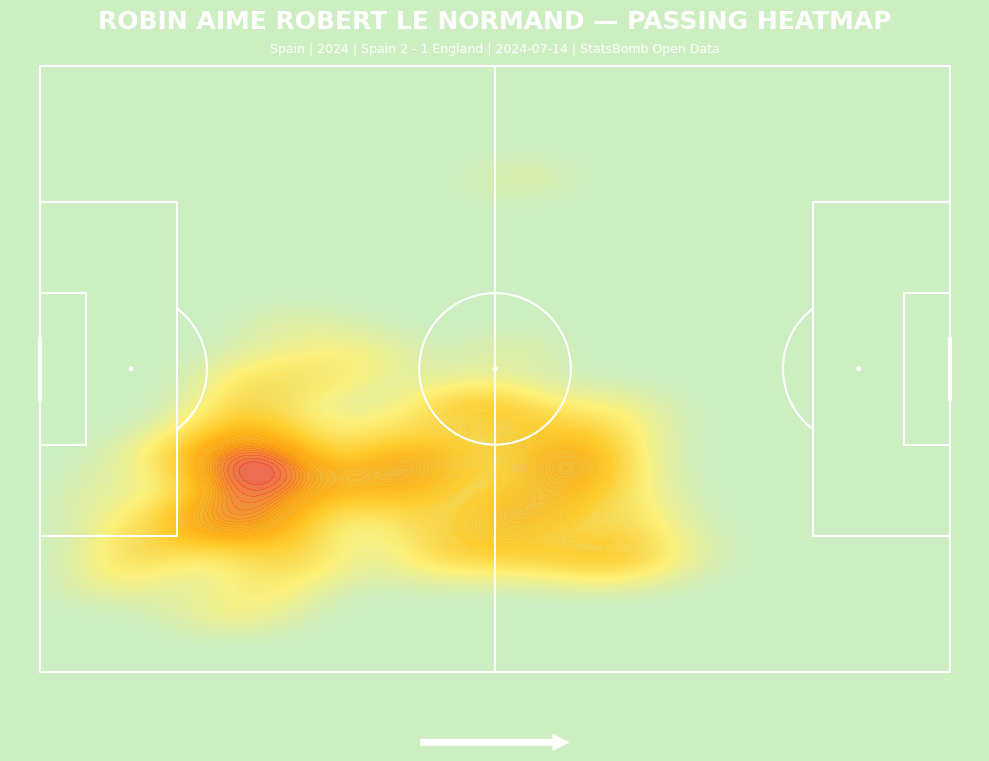

In [44]:
fig, ax = plot_pass_density_heatmap(
    passes=player_passes_clean,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source=DATA_SOURCE
)

plt.show()

In [45]:
def slugify_text(text):
    replacements = {
        " ": "_",
        "-": "_",
        "í": "i",
        "é": "e",
        "è": "e",
        "ê": "e",
        "á": "a",
        "à": "a",
        "â": "a",
        "ó": "o",
        "ò": "o",
        "ô": "o",
        "ú": "u",
        "ù": "u",
        "û": "u",
        "ñ": "n",
        "ç": "c",
    }

    text = text.lower()

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = "".join(
        character for character in text
        if character.isalnum() or character == "_"
    )

    while "__" in text:
        text = text.replace("__", "_")

    return text.strip("_")

In [46]:
player_slug = slugify_text(PLAYER_NAME)

HEATMAP_OUTPUT = Path("../outputs") / f"{player_slug}_pass_density_heatmap.png"

HEATMAP_OUTPUT

WindowsPath('../outputs/robin_aime_robert_le_normand_pass_density_heatmap.png')

In [47]:
fig.savefig(
    HEATMAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

In [48]:
HEATMAP_OUTPUT.exists()

True

In [49]:
HEATMAP_OUTPUT.resolve()

WindowsPath('E:/Documents/mosda/Projets/Data analyse/Projet 1 -Heatmap de passes d’un défenseur central/central-defender-pass-heatmap/outputs/robin_aime_robert_le_normand_pass_density_heatmap.png')

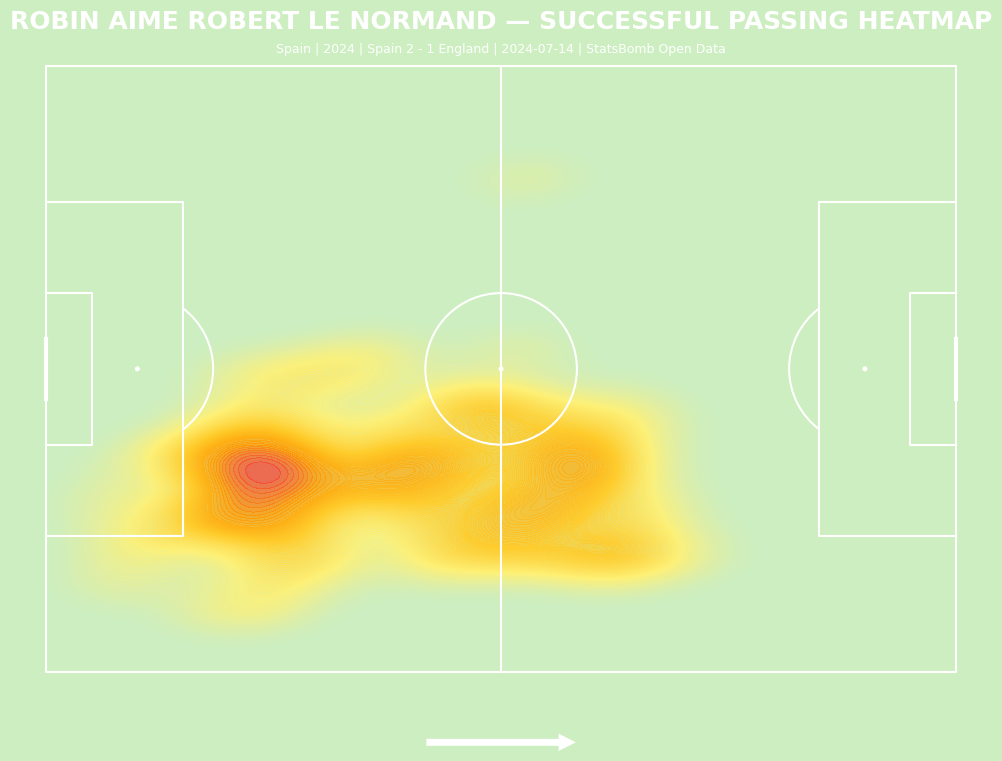

In [50]:
completed_player_passes = player_passes_clean[
    player_passes_clean["is_completed"]
].copy()

fig_completed, ax_completed = plot_pass_density_heatmap(
    passes=completed_player_passes,
    player_name=PLAYER_NAME,
    team_name=TEAM_NAME,
    season_label=SEASON_NAME,
    match_label=MATCH_LABEL,
    match_date=MATCH_DATE,
    source=DATA_SOURCE,
    title=f"{PLAYER_NAME.upper()} — SUCCESSFUL PASSING HEATMAP"
)

plt.show()

In [51]:
COMPLETED_HEATMAP_OUTPUT = Path("../outputs") / f"{player_slug}_successful_pass_density_heatmap.png"

fig_completed.savefig(
    COMPLETED_HEATMAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig_completed.get_facecolor()
)

COMPLETED_HEATMAP_OUTPUT.exists()

True